<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<html> <h1 style="font-style:italic; color:blue;"> Week-8 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Neural Networks in Finance </h2> </html>

### Silver: 6-months-2023 dataset
### LSTM (Long Short-Term Memory)
     
### Predictions of The Highest & Lowest prices DURING 25 following minutes
- Early-Stopping
- Loss function: MSE

### length of analysed history (sliding window)- 50 rows ~ 4 hours ago

#### dataset for training: 35.220 rows (5-minutes) = 6 months
#### train / test = 90 /10

_____________________![image.png](attachment:3c2be342-edd3-4b1a-be86-386ca3bc89e1.png)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

___________________![image.png](attachment:1ac70cfb-0de8-4f0f-96b9-a9036e865d16.png)

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

_____________________![image.png](attachment:bf9e6bfb-f12d-4987-a70f-1f020983c1da.png)

In [4]:
print(tf.__version__)

2.19.0


________________________![image.png](attachment:403bd3ea-d243-4143-9216-25a23e53dce2.png)

In [5]:
#Early Stopping librarires
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

<html> <h3 style="font-style:italic; color:blue;"> Data</h3> </html>

In [6]:
# A preprocessed and normalised dataset is used.
# The dataset includes indicators for the start of the day and the start of the week.

# We use different normalisation principles for prices. All Silver prices are divided by 10.
# We use the typical normalisation principle for Volumes and Deltas.

# For normalisation, it is not necessary for the normalised columns' values to be in the range between [0,1].
# What is more important is that all the values in these columns are approximately the same order of magnitude,
# i.e. do not differ by hundreds or more times.

_______________________![image.png](attachment:81fe8f1f-9cc4-48a0-bcdf-fd096abf3871.png)

In [7]:
df = pd.read_csv("Silver_6m_2023_normalised_NEW-10-1.csv")

df.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,2.4036,2.4059,2.4017,2.4059,0.000952,2.4102,2.4125,2.4083,2.4125,0.000960,0.133180,0.000009,0.840686,0.840686,0.840686,0.840686,1,1,2.4059,2.4083
1,2.4064,2.4130,2.4064,2.4092,0.005048,2.4094,2.4188,2.4094,2.4141,0.003159,0.131287,0.002175,0.928922,0.860294,0.928922,0.882353,0,0,2.4130,2.4094
2,2.4094,2.4098,2.3972,2.3977,0.002470,2.4143,2.4148,2.4022,2.4027,0.002412,0.133115,0.000066,0.882353,0.879902,0.879902,0.879902,0,0,2.4098,2.4022
3,2.3977,2.3980,2.3938,2.3980,0.002445,2.4026,2.4028,2.3986,2.4028,0.002445,0.133172,0.000000,0.882353,0.884804,0.884804,0.884804,0,0,2.3980,2.3986
4,2.3978,2.4024,2.3976,2.4023,0.002429,2.4026,2.4073,2.4023,2.4073,0.002474,0.133217,0.000052,0.884804,0.882353,0.887255,0.879902,0,0,2.4024,2.4023


_________________________![image.png](attachment:0249d3b8-764d-481e-95d7-7ec3ad9ba1ce.png)

In [8]:
df.tail()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
35215,2.2752,2.2752,2.2741,2.2746,0.000753,2.2782,2.2782,2.2771,2.2776,0.004924,0.137334,0.004802,0.928922,0.928922,0.928922,0.928922,0,0,2.2752,2.2771
35216,2.2736,2.2751,2.2736,2.2746,0.000386,2.2775,2.2781,2.2775,2.2776,0.002070,0.134853,0.001939,0.906863,0.928922,0.906863,0.928922,0,0,2.2751,2.2775
35217,2.2751,2.2751,2.2746,2.2746,0.000189,2.2781,2.2781,2.2776,2.2776,0.001152,0.134133,0.001109,0.928922,0.928922,0.928922,0.928922,0,0,2.2751,2.2776
35218,2.2746,2.2761,2.2736,2.2756,0.000591,2.2776,2.2797,2.2774,2.2786,0.001870,0.134448,0.001472,0.928922,0.914216,0.909314,0.928922,0,0,2.2761,2.2774
35219,2.2756,2.2766,2.2701,2.2745,0.000894,2.2786,2.2811,2.2786,2.2811,0.001015,0.133293,0.000139,0.928922,0.892157,0.794118,0.840686,0,0,2.2766,2.2786


____________________![image.png](attachment:f2355030-56c4-49bd-ad45-64f72c0e4a13.png)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35220 non-null  float64
 1   High_Bid          35220 non-null  float64
 2   Low_Bid           35220 non-null  float64
 3   Close_Bid         35220 non-null  float64
 4   Volume_Bid        35220 non-null  float64
 5   Open_Ask          35220 non-null  float64
 6   High_Ask          35220 non-null  float64
 7   Low_Ask           35220 non-null  float64
 8   Close_Ask         35220 non-null  float64
 9   Volume_Ask        35220 non-null  float64
 10  Volume_Delta      35220 non-null  float64
 11  Volume_Delta_abs  35220 non-null  float64
 12  Open_Delta        35220 non-null  float64
 13  High_Delta        35220 non-null  float64
 14  Low_Delta         35220 non-null  float64
 15  Close_Delta       35220 non-null  float64
 16  New_day           35220 non-null  int64 

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [10]:
# memory size reduction

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_day', 'New_week']



_________________________![image.png](attachment:c0f8d1c2-9119-4617-b120-858be9c1f345.png)

In [11]:
for column in columns_float:
    df[column] = pd.to_numeric(df[column], downcast='float')

for column in columns_integer:
    df[column] = pd.to_numeric(df[column], downcast='integer')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35220 non-null  float32
 1   High_Bid          35220 non-null  float32
 2   Low_Bid           35220 non-null  float32
 3   Close_Bid         35220 non-null  float32
 4   Volume_Bid        35220 non-null  float32
 5   Open_Ask          35220 non-null  float32
 6   High_Ask          35220 non-null  float32
 7   Low_Ask           35220 non-null  float32
 8   Close_Ask         35220 non-null  float32
 9   Volume_Ask        35220 non-null  float32
 10  Volume_Delta      35220 non-null  float32
 11  Volume_Delta_abs  35220 non-null  float32
 12  Open_Delta        35220 non-null  float32
 13  High_Delta        35220 non-null  float32
 14  Low_Delta         35220 non-null  float32
 15  Close_Delta       35220 non-null  float32
 16  New_day           35220 non-null  int8  

__________________________![image.png](attachment:edb9fcb4-3353-4009-9a00-204a6a3cd66c.png)

In [12]:
df.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
count,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,3.522000e+04,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000
mean,2.335737,2.337461,2.333843,2.335737,0.022654,2.338758,2.340482,2.336870,2.338750,0.095985,0.206354,0.084729,0.928403,0.928402,9.282691e-01,0.928593,0.003634,0.000738,2.337461,2.336870
std,0.136878,0.136883,0.136893,0.136887,0.024550,0.136878,0.136879,0.136895,0.136886,0.106733,0.091225,0.104995,0.007956,0.008288,1.229153e-02,0.009445,0.060176,0.027161,0.136883,0.136895
min,1.989300,1.991400,1.988800,1.989300,0.000000,1.992300,1.994400,1.991800,1.992300,0.000000,0.000000,0.000000,0.549020,0.458333,2.585078e-15,0.245098,0.000000,0.000000,1.991400,1.991800
25%,2.242175,2.244000,2.240000,2.242100,0.007141,2.245200,2.247000,2.243000,2.245100,0.025894,0.147285,0.016490,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.244000,2.243000
50%,2.356000,2.357600,2.354300,2.356000,0.014580,2.359000,2.360700,2.357300,2.359000,0.060819,0.173862,0.047034,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.357600,2.357300
75%,2.412200,2.414400,2.410300,2.412200,0.029227,2.415300,2.417400,2.413300,2.415200,0.127558,0.231854,0.113856,0.928922,0.928922,9.289216e-01,0.928922,0.000000,0.000000,2.414400,2.413300
max,2.611800,2.612300,2.609800,2.611800,0.329981,2.614800,2.615300,2.612800,2.614800,1.000000,1.000000,1.000000,0.975490,0.958333,1.000000e+00,0.973039,1.000000,1.000000,2.612300,2.612800


________________________![image.png](attachment:d6be8a47-2bfd-48a8-8094-a1d0704a9519.png)

In [13]:
df.shape

(35220, 20)

<html> <h3 style="font-style:italic; color:blue;"> Data Visualisation </h3> </html>

____________________![image.png](attachment:3a712fce-a669-403a-b7a6-54a65d7117c1.png)

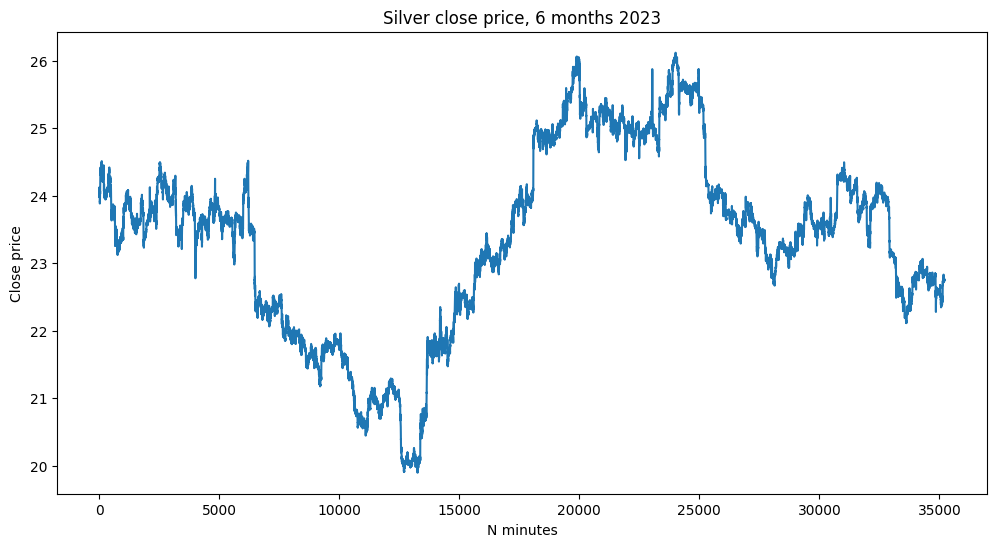

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df['Close_Bid']*10)

plt.title('Silver close price, 6 months 2023')
plt.xlabel('N minutes')
plt.ylabel('Close price')

plt.show()

__________________________![image.png](attachment:2cc199a5-7937-48cf-a78a-7d1e800dd6b2.png)

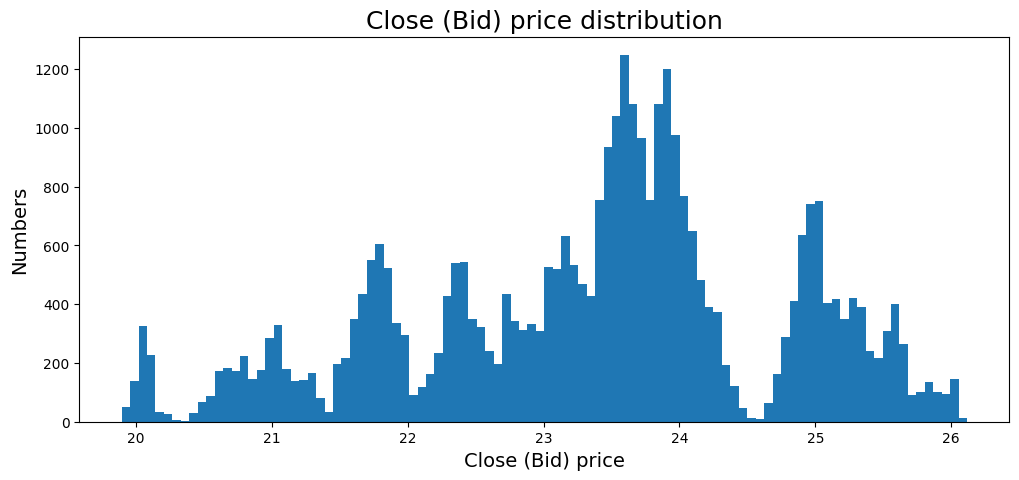

In [15]:
plt.figure(num=1, figsize=(12,5))
plt.hist(df['Close_Bid']*10, bins=100)

plt.title('Close (Bid) price distribution', size=18)
plt.ylabel('Numbers', size=14)
plt.xlabel('Close (Bid) price', size=14)

plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

<Figure size 1200x500 with 0 Axes>

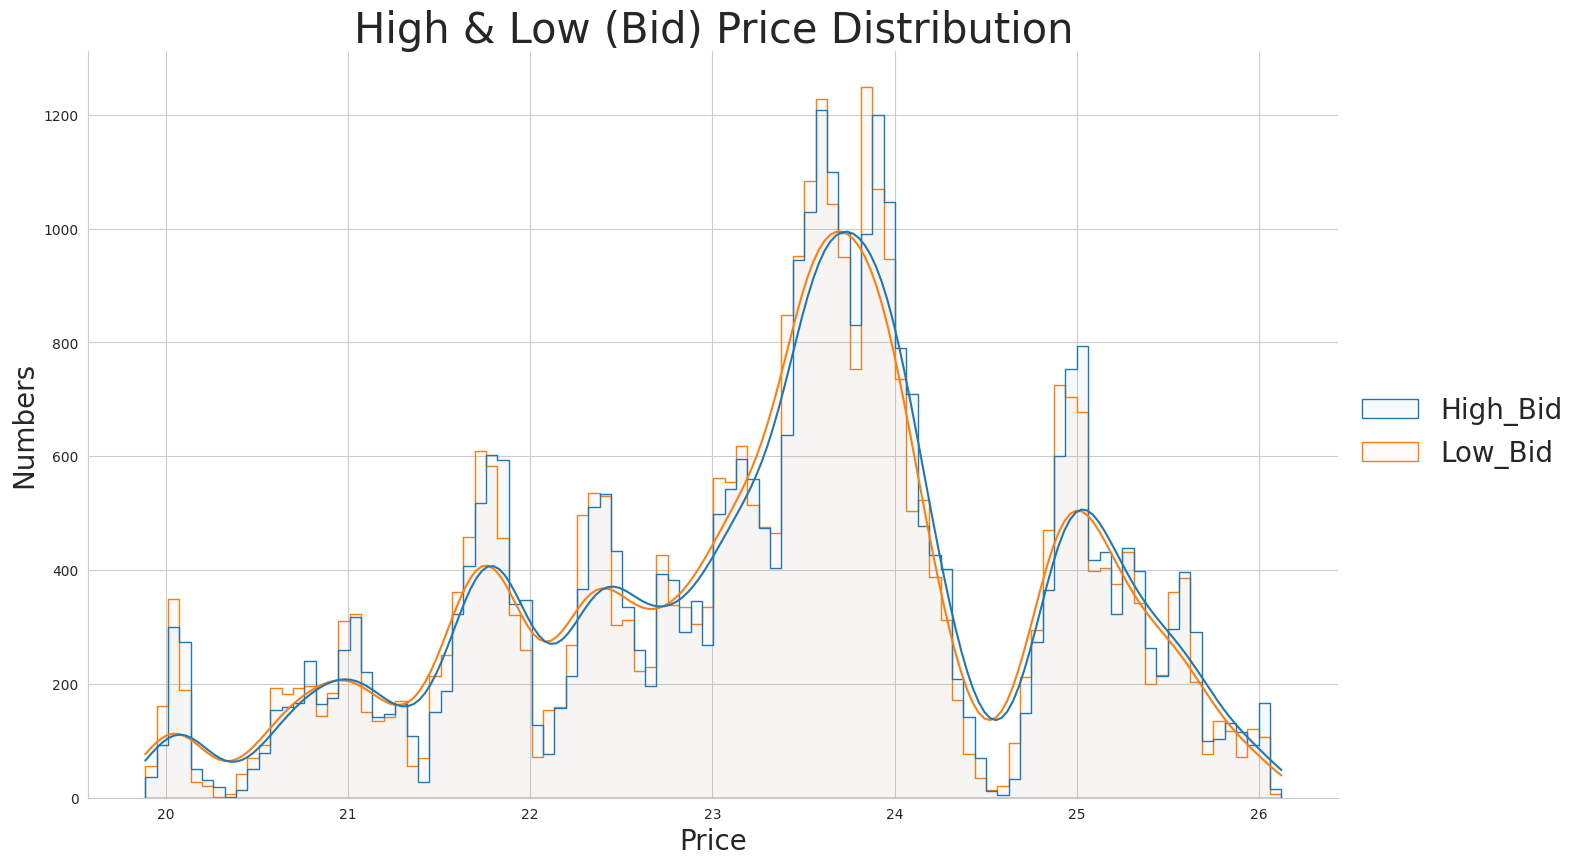

In [16]:
fig = plt.figure(figsize=(12,5))

plt.rc('axes', titlesize=30)

sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize':20.0})

sns.displot(
    df[['High_Bid','Low_Bid']]*10,
    height=8,
    aspect=1.7,
    kde=True,
    element="step",
    bins=100,
    alpha=0.03
)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size=20)
plt.ylabel('Numbers', size=20)

plt.show()

__________________________![image.png](attachment:a2f9a895-1a3d-466c-a713-d71969c76483.png)

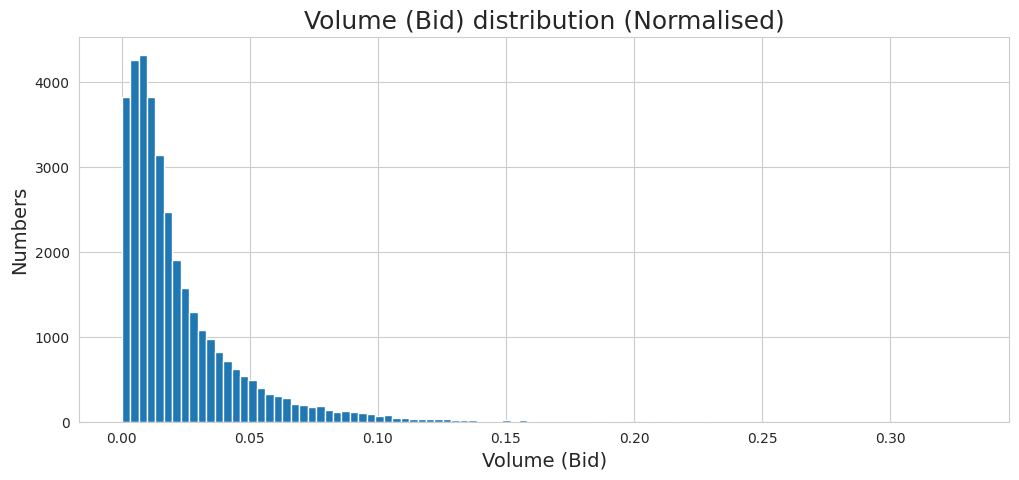

In [17]:
plt.figure(num=1,figsize=(12,5))
plt.hist(df['Volume_Bid'],bins=100)
plt.title('Volume (Bid) distribution (Normalised)',size=18)
plt.ylabel('Numbers',size=14)
plt.xlabel('Volume (Bid)',size=14)
plt.show();

<Figure size 1200x500 with 0 Axes>

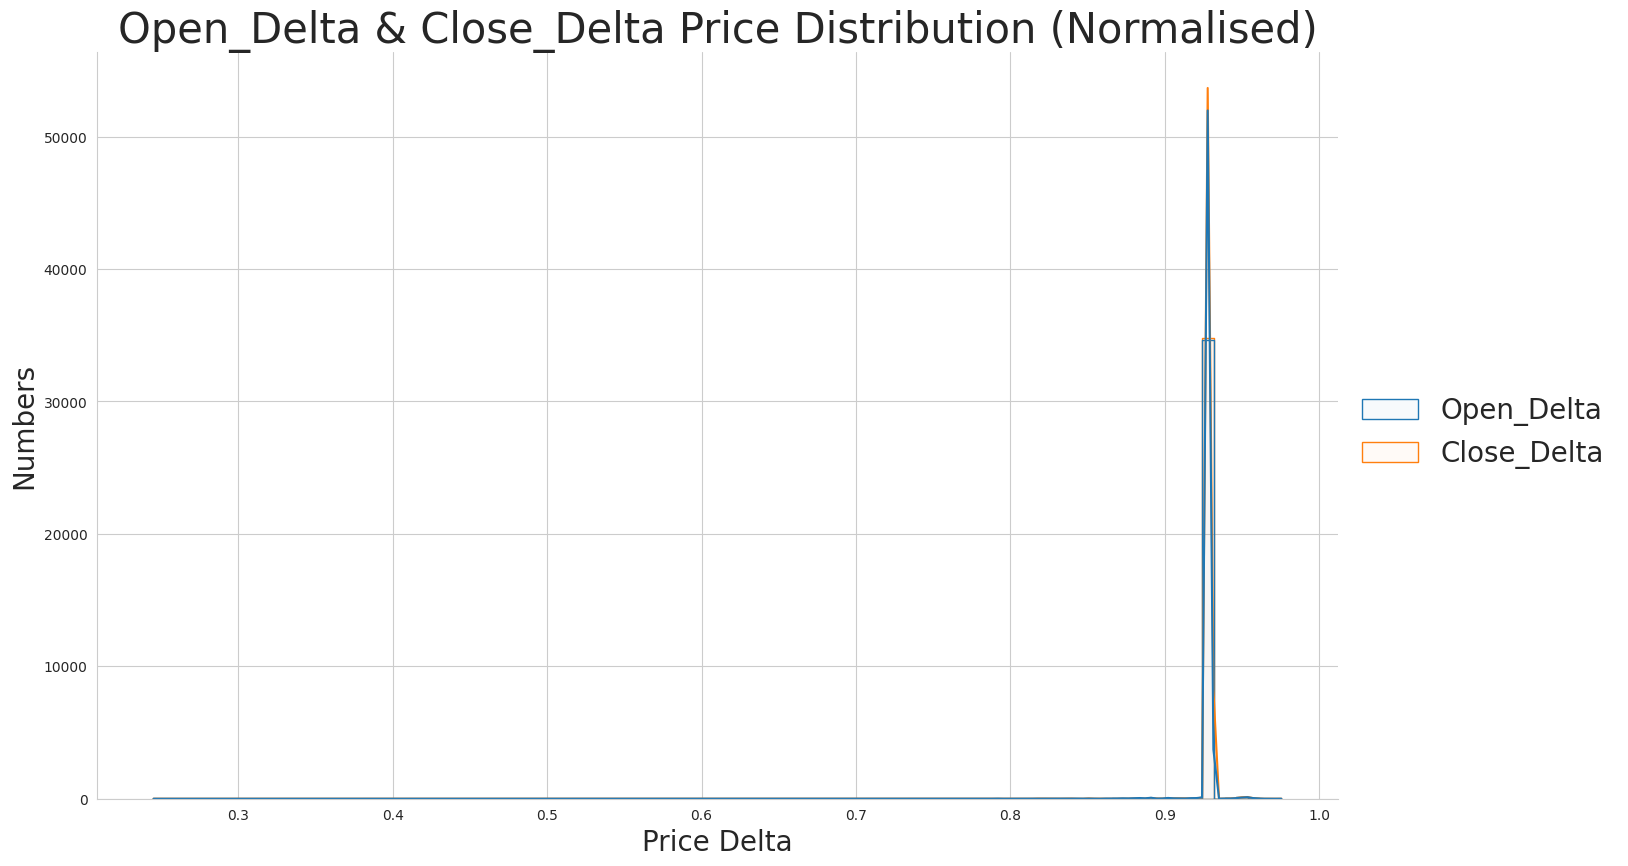

In [18]:
fig = plt.figure(figsize=(12, 5))

plt.rc('axes', titlesize=30)

sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize':20.0})

sns.displot(
    df[['Open_Delta','Close_Delta']],
    height=8,
    aspect=1.7,
    kde=True,
    element="step",
    bins=100,
    alpha=0.03
)

plt.title('Open_Delta & Close_Delta Price Distribution (Normalised)')
plt.xlabel('Price Delta', size=20)
plt.ylabel('Numbers', size=20)

plt.show()

_____________________________![image.png](attachment:12bce36a-a757-4dc4-ae6e-2f6c180f761a.png)

In [19]:
# Hint: To avoid typing the following code from scratch,
# you can copy the similar code above and modify it slightly.

<html> <h3 style="font-style:italic; color:blue;">Date transformation </h3> </html>


In [20]:
# We will predict the Highest and Lowest prices DURING the next 25 minutes (5rows * 5-minute time-frame).

# To do this in the data output (vector of answers), we shift prices sequentially to 25 minutes up (5rows),
# and find max and min prices during these 25 minutes
# Then you need to delete the 5 last rows since there are no prices for the next 25 minutes.
# Therefore, we will create an array of answers "data_ay" with the Highest and Lowest prices shifted sequentially to 5 rows up.

________________![image.png](attachment:2a9c8ffa-fa10-41a4-8429-54912b6dc2b1.png)

In [21]:
n = df.shape[0]
n

35220

________________![image.png](attachment:d5c1ae8c-6b92-4966-b2c8-9df405b2fda6.png)

In [22]:
p = df.shape[1]
p

20

__________________________![image.png](attachment:c36e4924-4e87-44b5-bbc7-49aa8e34278e.png)

In [23]:
# create inputs Dataframe

data_ax = df.drop(['Y_High_Bid', 'Y_Low_Ask'], axis=1)

In [24]:
data_ax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35220 non-null  float32
 1   High_Bid          35220 non-null  float32
 2   Low_Bid           35220 non-null  float32
 3   Close_Bid         35220 non-null  float32
 4   Volume_Bid        35220 non-null  float32
 5   Open_Ask          35220 non-null  float32
 6   High_Ask          35220 non-null  float32
 7   Low_Ask           35220 non-null  float32
 8   Close_Ask         35220 non-null  float32
 9   Volume_Ask        35220 non-null  float32
 10  Volume_Delta      35220 non-null  float32
 11  Volume_Delta_abs  35220 non-null  float32
 12  Open_Delta        35220 non-null  float32
 13  High_Delta        35220 non-null  float32
 14  Low_Delta         35220 non-null  float32
 15  Close_Delta       35220 non-null  float32
 16  New_day           35220 non-null  int8  

___________________![image.png](attachment:0b147115-c247-44e0-9bd7-613e4dbadee3.png)

_______________________![image.png](attachment:51d737d1-606b-4909-9897-4b8361baf8ad.png)

In [25]:
data_ax.shape

(35220, 18)

____________________![image.png](attachment:0c1af6d8-caf4-41ff-a379-0b04bc31d76a.png)

In [26]:
# create outputs Dataframe
data_ay = df[['Y_High_Bid', 'Y_Low_Ask']]

_______________________![image.png](attachment:d8472011-cff7-4733-abcc-962f26df7aaa.png)

In [27]:
data_ay.shape

(35220, 2)

_________________________![image.png](attachment:9b68ca6a-117d-4a07-851f-6a34c089ad93.png)

In [28]:
data_ay.head(6)

,Y_High_Bid,Y_Low_Ask
0,2.4059,2.4083
1,2.4130,2.4094
2,2.4098,2.4022
3,2.3980,2.3986
4,2.4024,2.4023
5,2.4061,2.4073


_____________________________![image.png](attachment:69cb95d3-a271-4e45-a0e8-2cba04a808dc.png)

In [29]:
data_ay.tail(10)

,Y_High_Bid,Y_Low_Ask
35210,2.2760,2.2772
35211,2.2753,2.2768
35212,2.2753,2.2768
35213,2.2747,2.2758
35214,2.2752,2.2769
35215,2.2752,2.2771
35216,2.2751,2.2775
35217,2.2751,2.2776
35218,2.2761,2.2774
35219,2.2766,2.2786


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [30]:
# shift by one 5-minute(row) up
# We have to exclude the min and max prices of the current 5-minute row while further
# finding the min and max prices DURING the next 25 minutes

data_ay = data_ay.shift(-1)

_______________________![image.png](attachment:29e41a66-d339-4ade-9ea4-134099a9cf98.png)

In [31]:
data_ay.head(6)

,Y_High_Bid,Y_Low_Ask
0,2.4130,2.4094
1,2.4098,2.4022
2,2.3980,2.3986
3,2.4024,2.4023
4,2.4061,2.4073
5,2.4101,2.4090


_____________________![image.png](attachment:09ac21d9-9d8b-4a6a-bad9-5cb60ec9b080.png)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [32]:
# create new colomns: MIN_Lowest(Low_Ask) and MAX_Highest(High_Bid) prices of DURING NEXT 25 minutes

# Forward-looking window
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)

data_ay['Y_High_Bid_25'] = data_ay['Y_High_Bid'].rolling(window=indexer).max()
data_ay['Y_Low_Ask_25']  = data_ay['Y_Low_Ask'].rolling(window=indexer).min()

_______________________![image.png](attachment:2b67dc52-076a-4b7a-9744-d64705a2512e.png)

In [33]:
data_ay.head(10)

,Y_High_Bid,Y_Low_Ask,Y_High_Bid_25,Y_Low_Ask_25
0,2.4130,2.4094,2.4130,2.3986
1,2.4098,2.4022,2.4101,2.3986
2,2.3980,2.3986,2.4101,2.3986
3,2.4024,2.4023,2.4101,2.4023
4,2.4061,2.4073,2.4101,2.4062
5,2.4101,2.4090,2.4101,2.4062
6,2.4091,2.4062,2.4092,2.4062
7,2.4072,2.4072,2.4093,2.4072
8,2.4068,2.4078,2.4093,2.4076
9,2.4076,2.4083,2.4136,2.4076


_____________________________![image.png](attachment:aff4a0fc-2e7b-4052-89d3-4cbd122ce4de.png)

In [34]:
data_ay.tail(10)

,Y_High_Bid,Y_Low_Ask,Y_High_Bid_25,Y_Low_Ask_25
35210,2.2753,2.2768,2.2753,2.2758
35211,2.2753,2.2768,2.2753,2.2758
35212,2.2747,2.2758,2.2752,2.2758
35213,2.2752,2.2769,2.2761,2.2769
35214,2.2752,2.2771,2.2766,2.2771
35215,2.2751,2.2775,NaN,NaN
35216,2.2751,2.2776,NaN,NaN
35217,2.2761,2.2774,NaN,NaN
35218,2.2766,2.2786,NaN,NaN
35219,NaN,NaN,NaN,NaN


_________________________![image.png](attachment:7138496d-6950-49b0-a5c0-7a3bdc1b5e71.png)

In [35]:
# remove columns unused in further code
data_ay = data_ay.drop(['Y_High_Bid', 'Y_Low_Ask'], axis=1)

data_ay.tail(6)

,Y_High_Bid_25,Y_Low_Ask_25
35214,2.2766,2.2771
35215,NaN,NaN
35216,NaN,NaN
35217,NaN,NaN
35218,NaN,NaN
35219,NaN,NaN


_____________________![image.png](attachment:1fb96d2d-63cb-4a2d-814d-c22ace147394.png)

In [36]:
# delete the 5 last rows in data_ax and data_ay
# (because we don't have answers(outputs) for the last 25 minutes)

for i in range(5):
    data_ax.drop(data_ax.shape[0]-1, axis=0, inplace=True)
    data_ay.drop(data_ay.shape[0]-1, axis=0, inplace=True)

___________________![image.png](attachment:4b0076ad-ef38-43c6-88ed-64b6e59e78ee.png)

In [37]:
data_ay.shape

(35215, 2)

_____________________![image.png](attachment:a543ec8f-4dc8-4b78-ab2a-de2a50ac7e5a.png)

In [38]:
data_ay.tail(3)

,Y_High_Bid_25,Y_Low_Ask_25
35212,2.2752,2.2758
35213,2.2761,2.2769
35214,2.2766,2.2771


In [39]:
data_ax.shape

(35215, 18)

#### Create numpy

____________________![image.png](attachment:fe5264f6-032a-49ec-becd-7b327c6d89a8.png)

In [40]:
import numpy as np

if not isinstance(data_ax, np.ndarray):
    data_ax = data_ax.to_numpy()

if not isinstance(data_ay, np.ndarray):
    data_ay = data_ay.to_numpy()

print(data_ax.shape, "in", data_ay.shape)

(35215, 18) in (35215, 2)


<html> <h3 style="font-style:italic; color:blue;">Create the 3D inputs tensor, and 2D outputs matrix </h3> </html>

In [41]:
# We need a three-dimensional data tensor: [(n - N ), N, 18] and
# two-dimensional array of answers [(n - N ), 2] with the High and Low prices DURING the next 25 minutes

# where N=50 (equal to just over 4 hours) is the number of rows for analysis at each step; those are looking backwards

# Therefore, we need:
# three-dimensional data tensor of sliced graphs [(n - N - 5), N, 18] and
# two-dimensional matrix of answers Y[(n - N - 5), 2] with the High and Low prices shifted sequentially to 5 rows up.

________________________![image.png](attachment:b74766db-f69f-4828-89e4-1af849fa9f75.png)

In [42]:
from tqdm import tqdm

_______________________![image.png](attachment:2295f022-52dc-4098-9c79-10ad0c95d973.png)

In [43]:
n = len(data_ay)
print(n)

35215


____________________![image.png](attachment:70752c77-de5a-493d-bf2f-696656f4c30b.png)

In [44]:
N = 50                # sliding window depth
L = n - N             # number of sliding window slices
t = data_ax.shape[1]  # features number

print('Size of a three-dimensional inputs tensor:', L, N, t)

Size of a three-dimensional inputs tensor: 35165 50 18


___________________________![image.png](attachment:5d7b5027-87d0-4d62-b302-c4144c1c4ed9.png)

In [45]:
# create inputs zeros 3D tensors with 'float32'

data_b = np.zeros((L, N, t), dtype='float32')

In [46]:
# create a two-dimensional zeros vector of answers
# the High_Bid and Low_Ask prices DURING the next 25 minutes

Y = np.zeros((L, 2), dtype='float32')   # predicting 2 outputs

____________________________![image.png](attachment:09c7f53e-9b42-4b6d-872e-c27c0abc0485.png)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [47]:
# fill the inputs 3D tensor (data_b)
# and the matrix of outputs Y

print('L = n - N - 5 = ', n-N-5, L)

for k in tqdm(range(L)):
    data_b[k, :, :] = data_ax[k:k+N, :]

    Y[k,0] = data_ay[k+N-1,0]   # Y_High_Bid_25 - max 25 minutes future price
    Y[k,1] = data_ay[k+N-1,1]   # Y_Low_Ask_25 -  min 25 minutes future price

print(k) # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n - N - 5 =  35160 35165


100%|██████████| 35165/35165 [00:00<00:00, 208479.09it/s]

35164
data_b: 
 [[[2.4036     2.4059     2.4017     ... 0.84068626 1.         1.        ]
  [2.4064     2.413      2.4064     ... 0.88235295 0.         0.        ]
  [2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  ...
  [2.4218     2.4251     2.4212     ... 0.9289216  0.         0.        ]
  [2.4234     2.4255     2.422      ... 0.9289216  0.         0.        ]
  [2.4244     2.435      2.4237     ... 0.9289216  0.         0.        ]]

 [[2.4064     2.413      2.4064     ... 0.88235295 0.         0.        ]
  [2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  [2.3977     2.398      2.3938     ... 0.88480395 0.         0.        ]
  ...
  [2.4234     2.4255     2.422      ... 0.9289216  0.         0.        ]
  [2.4244     2.435      2.4237     ... 0.9289216  0.         0.        ]
  [2.4345     2.435      2.4309     ... 0.9289216  0.         0.        ]]

 [[2.4094     2.4098     2.3972     ... 0.87990195 0.         0.        ]
  [2.3

__________________________![image.png](attachment:ee53594d-2d24-49c6-b114-e898289d63b7.png)

In [48]:
# Control of the correctness of filling the array Y
# (should show MAX of the normalised prices High_Bid and Low_Ask during next 25 minutes (5-step ahead))

import random

pp = random.randint(50, L)   # random number less than total windows
print('random int =', pp)

print('data_b:', '\t\t', 'Y:')
print('Y_High_Bid', '\t\t', 'Y_High_Bid')

for i in range(15):
    print(data_b[pp + i, N-1, 1], '\t\t', Y[pp + i, 0])

random int = 22441
data_b: 		 Y:
Y_High_Bid 		 Y_High_Bid
2.4932 		 2.4839
2.4839 		 2.4717
2.4717 		 2.4683
2.4683 		 2.4656
2.4638 		 2.4736
2.4649 		 2.4764
2.4592 		 2.4896
2.4633 		 2.4918
2.4656 		 2.4943
2.4736 		 2.4943
2.4764 		 2.4943
2.4896 		 2.4943
2.4918 		 2.4943
2.4943 		 2.4909
2.4909 		 2.4854


In [49]:
# Each rows of Y above must have maximum of prices of 5 row ahead

__________________![image.png](attachment:72bcd11b-0d4d-48b1-a3a9-b69093ca47f6.png)

<html> <h3 style="font-style:italic; color:blue;">Train Test Split </h3> </html>

- 90% for training and validation
- 10% for testing

_______________________![image.png](attachment:0a63f726-5b62-4ca5-a82d-c25bc5587bc1.png)

In [50]:
from sklearn.model_selection import train_test_split

<html> <h3 style="font-style:bold; color:red;"> !!! Use parameters: shuffle = False, stratify = None

Otherwise, the whole time series will be mixed up!
</h3> </html>

___________________________![image.png](attachment:c9ba42cb-b0d5-445b-944a-c5eda99927ab.png)

In [51]:
from sklearn.model_selection import train_test_split

# Separate data_b and Y into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    data_b,
    Y,
    test_size=0.1,
    shuffle=False
)

In [55]:
# Final control
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(31648, 50, 18)
(31648, 2)
(3517, 50, 18)
(3517, 2)


______________________________![image.png](attachment:d4e18d00-7394-4955-9134-e30ed514608b.png)

<html> <h3 style="font-style:italic; color:blue;">Training </h3> </html>

____________________________![image.png](attachment:42707ca1-fd73-4890-bf27-2fa8e0fced4f.png)

In [62]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.LSTM(100, activation='relu', input_shape=(50, 18)),
    keras.layers.Dense(2)
])

_______________________________![image.png](attachment:34b70a72-48dd-4387-9c39-e61ed778f0bb.png)

In [63]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        47,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,802 (186.73 KB)

 Trainable params: 47,802 (186.73 KB)

 Non-trainable params: 0 (0.00 B)

None


In [64]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

_____________________________![image.png](attachment:6cb76392-909e-4305-9711-31c9c70002a1.png)

#### Callbacks

___________________________![image.png](attachment:ffd13595-9a91-4bfd-aa58-5b7193261341.png)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=7,
    verbose=1
)

mc = ModelCheckpoint(
    'best_model_LSTM_Silver_3D_Tensor.keras',
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_best_only=True
)

<html> <h4 style="font-style:bold; color:red;"> If you are using your own laptop without a GPU (Graphics processing unit),

please change the following parameter in the next cell

epochs=10
</h4> </html>


___________________________![image.png](attachment:a94cf39a-a667-40ce-aa27-edb8086ea2e6.png)

In [69]:
history = model.fit(
    X_train,
    y_train,
    batch_size=20,
    epochs=20,
    validation_split=0.1,
    verbose=1,
    callbacks=[es, mc]
)

Epoch 1/20
1418/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6247e-05 - mae: 0.0068
Epoch 1: val_loss improved from inf to 0.00003, saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 7.6207e-05 - mae: 0.0068 - val_loss: 2.7522e-05 - val_mae: 0.0041
Epoch 2/20
1420/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1404e-05 - mae: 0.0061
Epoch 2: val_loss did not improve from 0.00003
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 6.1418e-05 - mae: 0.0061 - val_loss: 1.0349e-04 - val_mae: 0.0090
Epoch 3/20
1420/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5803e-05 - mae: 0.0057
Epoch 3: val_loss did not improve from 0.00003
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5.5794e-05 - mae: 0.0057 - val_loss: 1.0880e-04 - val_mae: 0.0097
Epoch 4/20
1422/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9316e-05 - mae: 0.0059
Epoch 4: val_loss improved from 0.00003 to 0.00002, saving model to best_model_LSTM_Silver_3D_Tensor.k

____________________________![image.png](attachment:42c20416-bba2-4c5d-b61c-25dead55d91f.png)

In [70]:
# Upload the saved best model
LSTM_saved_best_model_Silver_3D = keras.models.load_model(
    'best_model_LSTM_Silver_3D_Tensor.keras'
)

#### Test

____________________________![image.png](attachment:d0619fb2-a60b-4a2c-888c-6064d7f0a11f.png)

In [71]:
# Evaluate the quality of network training on test data, which the network has NOT seen
scores = LSTM_saved_best_model_Silver_3D.evaluate(
    X_test,
    y_test,
    verbose=1
)

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.7624e-05 - mae: 0.0030


_______________________![image.png](attachment:9bf86c3d-b133-43f9-be7c-870af2b20322.png)

In [72]:
print("Test MSE:", scores[0])
print("Test MAE:", scores[1])

Test MSE: 1.695657556410879e-05
Test MAE: 0.0029644847381860018


_______________________![image.png](attachment:282f12ec-889c-4a0a-ad43-9b890fe24950.png)

________________________![image.png](attachment:fc2efb04-14a6-4f0b-9302-6a454afd8cd5.png)

### Visualisation

#### MSE graphs during training

__________________________________![image.png](attachment:4e60e7b3-e05a-424d-9848-9321be42e30b.png)

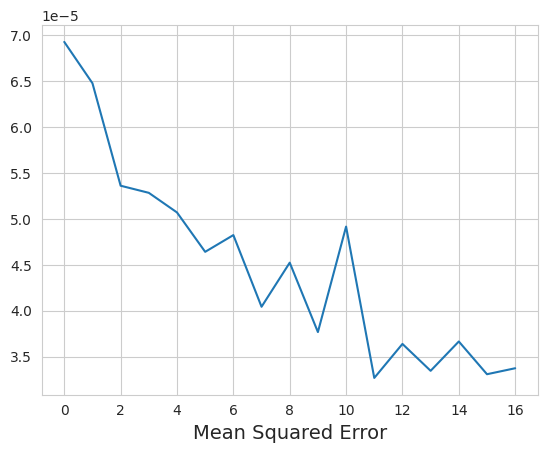

In [74]:
# Training Mean Squared Error (MSE)

plt.plot(history.history['loss'])
plt.xlabel('Mean Squared Error', size=14)

plt.show()

____________________________![image.png](attachment:0a2361cd-91d8-47fc-836c-e6d0fa8c2cfc.png)

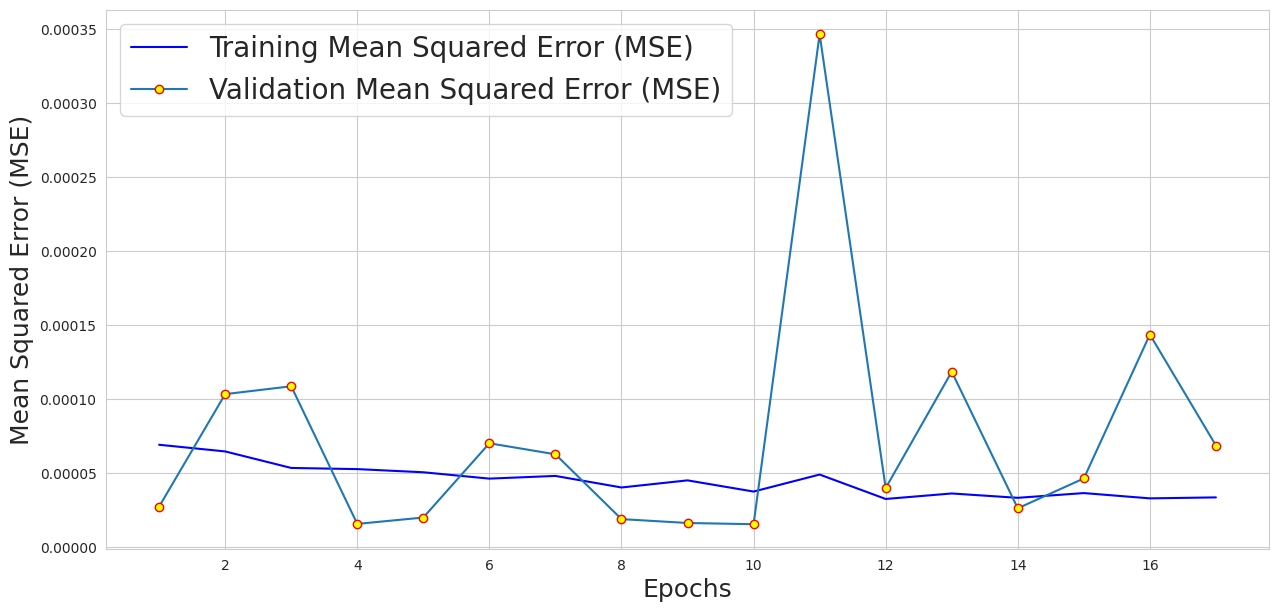

In [75]:
# More detailed MSE graph

history_dict = history.history

mse_values = history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')
plt.plot(epochs, val_mse_values,
         marker='o',
         markeredgecolor='red',
         markerfacecolor='yellow',
         label='Validation Mean Squared Error (MSE)')

plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)

plt.legend()
plt.show()

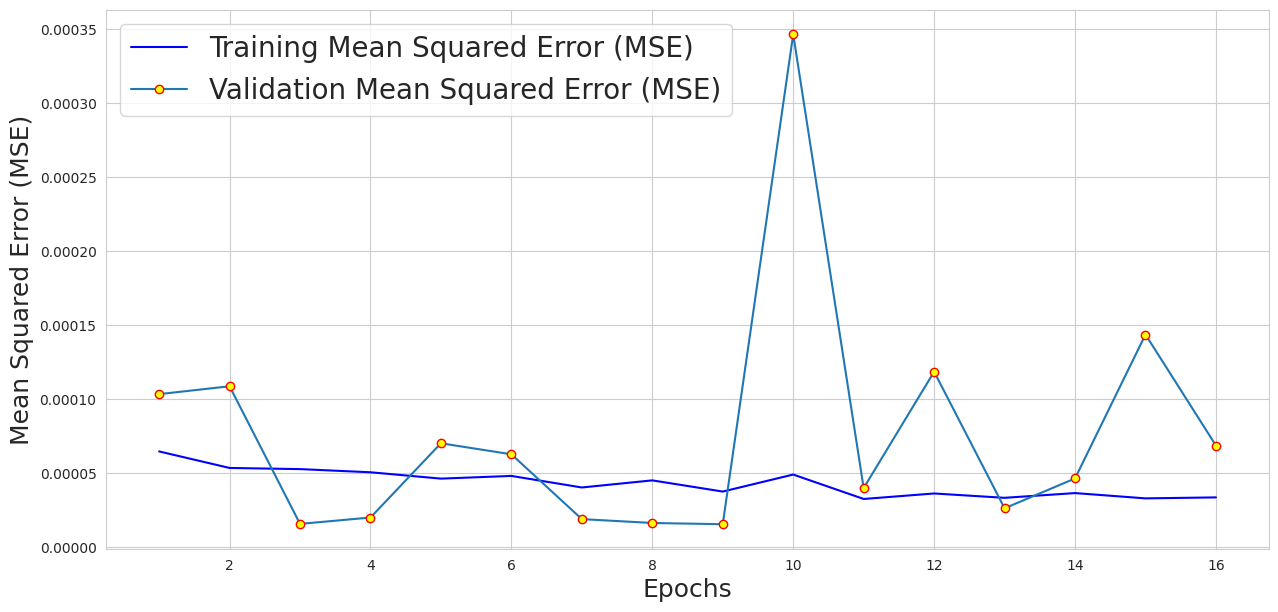

In [76]:
# deleted the 1st epoch
# to examine in detail the results of the remaining epochs

history_dict = history.history

mse_values = history_dict['loss'][1:]
val_mse_values = history_dict['val_loss'][1:]

epochs = range(1, len(mse_values) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')

plt.plot(
    epochs,
    val_mse_values,
    marker='o',
    markeredgecolor='red',
    markerfacecolor='yellow',
    label='Validation Mean Squared Error (MSE)'
)

plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)

plt.legend()
plt.show()

In [52]:
# Hint: To avoid typing the following code from scratch,
# you can copy the similar code above and modify it slightly.

________________![image.png](attachment:82020776-b3a3-4d11-8937-d1bd77bcef05.png)

#### MAE graphs during training

________________________![image.png](attachment:92a7eee3-b170-4b85-a571-3b9b764f0cd2.png)

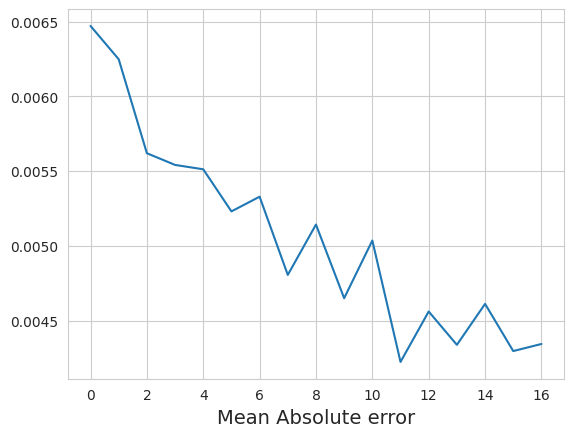

In [77]:
# Training Mean Absolute Error (MAE)

plt.plot(history.history['mae'])
plt.xlabel('Mean Absolute error', size=14)
plt.show()

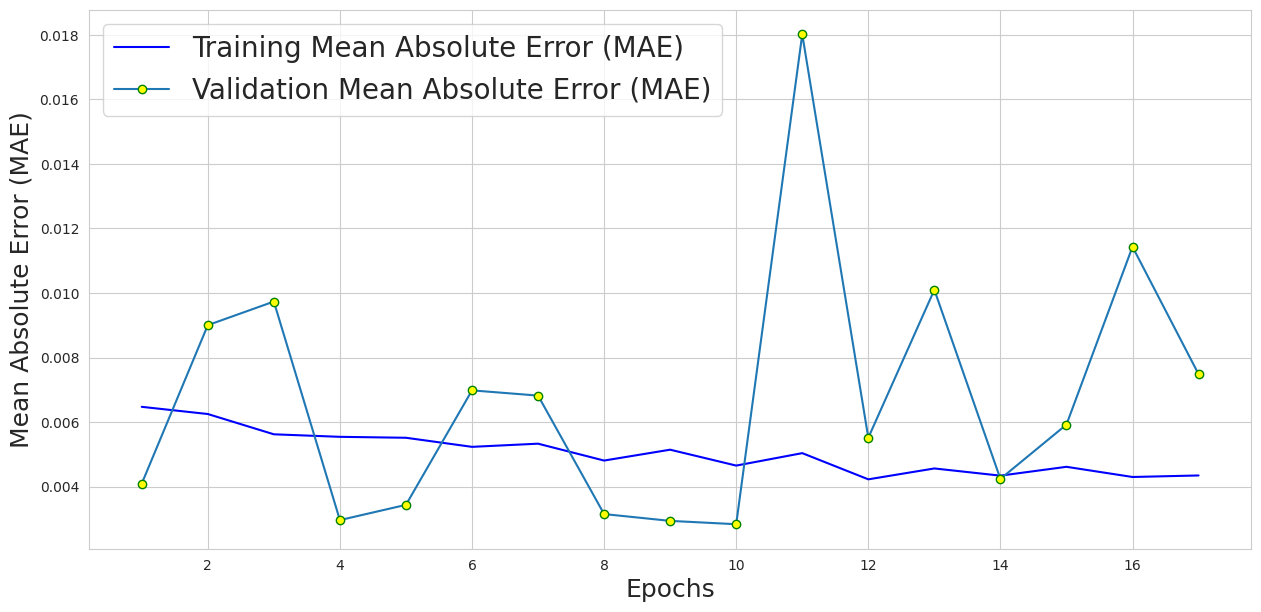

In [78]:
# More detailed MAE graph

history_dict = history.history

mae_values = history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(epochs, mae_values, 'b', label='Training Mean Absolute Error (MAE)')

plt.plot(
    epochs,
    val_mae_values,
    marker='o',
    markeredgecolor='green',
    markerfacecolor='yellow',
    label='Validation Mean Absolute Error (MAE)'
)

plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Absolute Error (MAE)', size=18)

plt.legend()
plt.show()

In [53]:
# Hint: To avoid typing the following code from scratch,
# you can copy the similar code above and modify it slightly.

__________________________![image.png](attachment:2c212167-80dd-4371-baca-1030a76ec04d.png)

### prediction 25 minute ahead

____________________![image.png](attachment:73ffd6f9-49ec-4974-8d05-772edf77b107.png)

In [79]:
# prediction 25 minute ahead

pred = LSTM_saved_best_model_Silver_3D(X_test)

print(pred)

tf.Tensor(
[[2.3718033 2.3705828]
 [2.3731434 2.3711505]
 [2.3744493 2.3724246]
 ...
 [2.2788134 2.2778254]
 [2.2786388 2.277717 ]
 [2.2779276 2.2770667]], shape=(3517, 2), dtype=float32)


In [80]:
len(pred)

3517

__________________________![image.png](attachment:0c3dbf9f-b5f8-4af3-88eb-46863e18a490.png)

### Price chart

________________________![image.png](attachment:b5a95cea-fdc6-4a0c-af43-9cc7e6720be8.png)

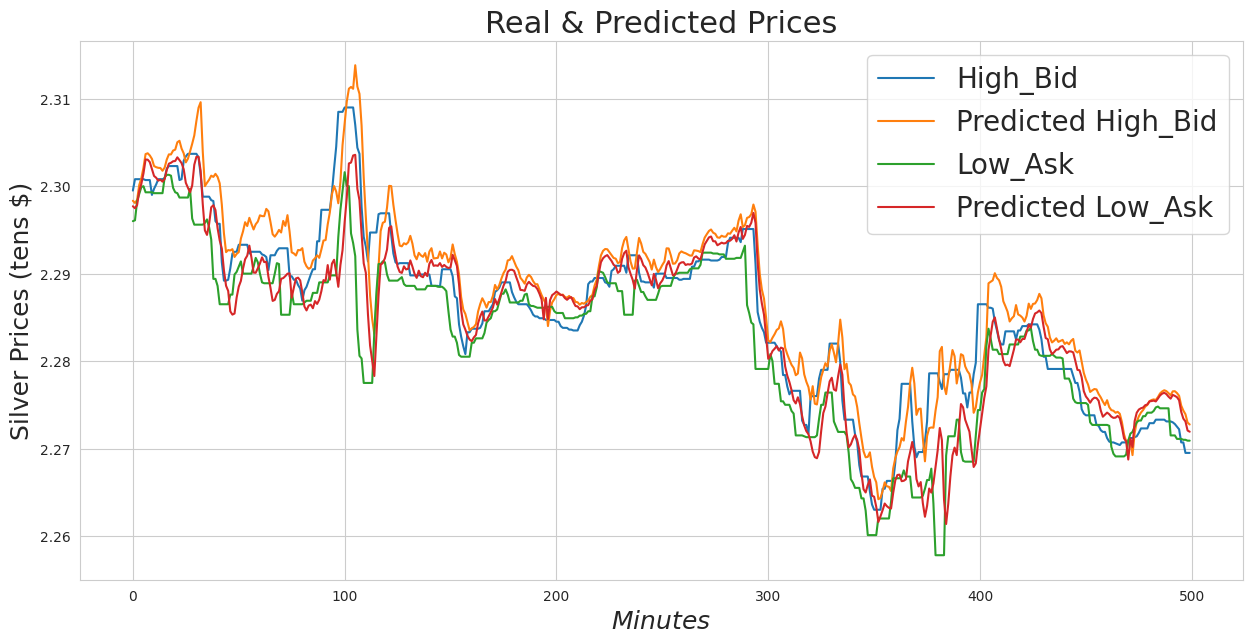

In [81]:
# Chart range
N1 = 2500   # The first minute for the chart
LL = 500    # Duration (in minutes) for the chart
N2 = N1 + LL  # The last minute for the chart

plt.ion()

fig = plt.figure(figsize=(15,7))

ax1 = fig.add_subplot(111)

line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')

line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & Predicted Prices', size=22)
plt.ylabel('Silver Prices (tens $)', size=18)
plt.xlabel('$Minutes$', size=18)

plt.legend(loc='upper right')

plt.show()

### Error Chart

____________________![image.png](attachment:7bf2f9cb-8f93-4c69-bd94-cfaa094365b6.png)

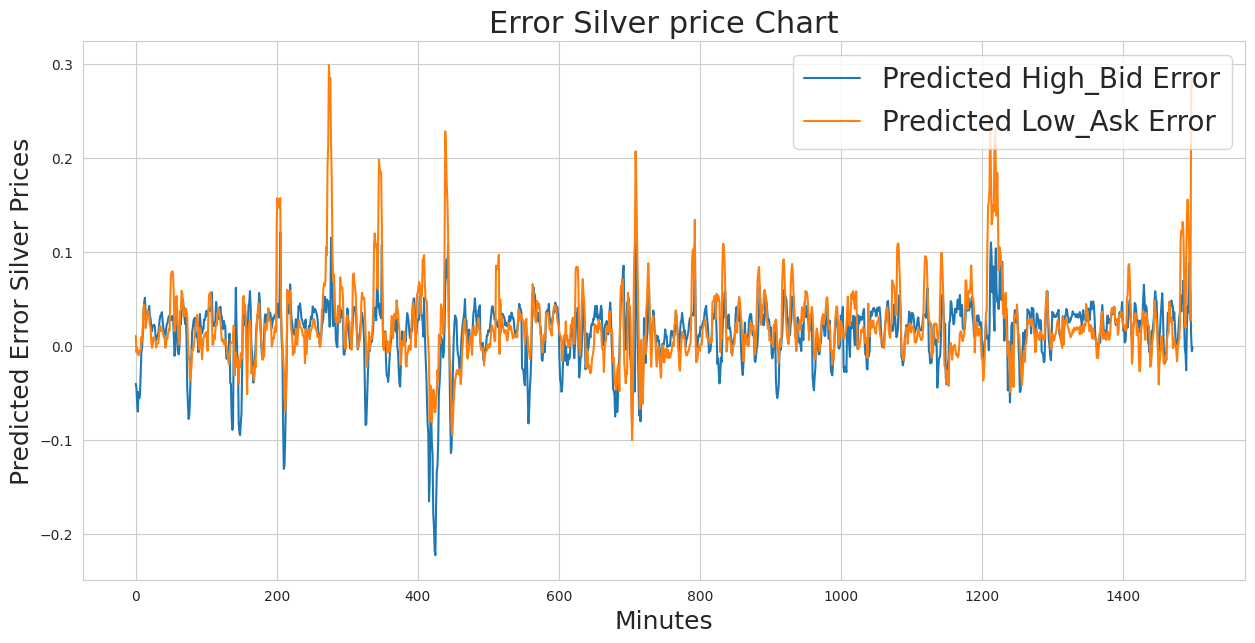

In [83]:
# For 6 months 2023
max_price = 26.153
min_price = 19.888
average_price = (max_price + min_price) / 2


# Chart range
N1 = 0      # The first minute for the chart
LL = 1500   # Length (in minutes) for the chart
N2 = N1 + LL


plt.ion()
fig = plt.figure(figsize=(15,7))

ax1 = fig.add_subplot(111)

# absolute price error in dollars
a = (pred[N1:N2,0] - y_test[N1:N2,0]) * 10
b = (pred[N1:N2,1] - y_test[N1:N2,1]) * 10

line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error Silver price Chart', size=22)
plt.ylabel('Predicted Error Silver Prices', size=18)
plt.xlabel('Minutes', size=18)

plt.legend(loc='upper right')

plt.show()

In [54]:
# Hint: To avoid typing the following code from scratch,
# you can copy the similar code above and modify it slightly.

____________________![image.png](attachment:f4784ad6-2915-40ff-acf1-dd35e76946c4.png)

# Lab Logbook Requirement:

<html> <h3 style="font-style:italic; color:blue;">
   
1) Modify the practical session LSTM model parameter from 100 to be calculated using the formula:

   ZY + 10
   , where your SID is: XXXXXZY

   For example, if your SID is 2287167,
   LSTM parameter = 67+10 = 77
   
3) Change the epochs to 10
4) Change the patience to 5
5) Leave other parameters the same as in the practical session.
6) Compile the model.
6) Train your LSTM with the same datasets and demonstrate the received test MSE & MAE.
Compare your test MSE & MAE with the MSE & MAE of the LSTM in the practical session.
7) Please only add to your Lab Logbook print-screens of:
- your LSTM architecture using model.summary()
- code and training result using model.fit()
- the resulting test MSE & MAE and
- MAE detailed graph.
    
</h3> </html>

<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.
</h3> </html>

In [84]:
# STEP 1: Define LSTM units using SID formula

ZY = 67   # Replace with the last two digits of your SID
LSTM_UNITS = ZY + 10

print("LSTM Units:", LSTM_UNITS)

LSTM Units: 77


In [85]:
# STEP 2: Set training epochs

EPOCHS = 10
print("Training epochs:", EPOCHS)

Training epochs: 10


In [86]:
# STEP 3: EarlyStopping configuration

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1
)

mc = ModelCheckpoint(
    'best_model_LSTM_Silver_3D_Tensor.keras',
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_best_only=True
)

In [88]:
# STEP 4: Build LSTM model

from tensorflow import keras

model = keras.Sequential([

    keras.layers.LSTM(
        LSTM_UNITS,
        activation='relu',
        input_shape=(50, 18)
    ),

    keras.layers.Dense(2)
])

In [93]:
# Display the architecture of the LSTM model

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 77)             │        29,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,174 (348.34 KB)

 Trainable params: 29,724 (116.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,450 (232.23 KB)

In [89]:
# STEP 5: Compile model

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [90]:
# STEP 6: Train LSTM model

history = model.fit(
    X_train,
    y_train,
    batch_size=20,
    epochs=10,
    validation_split=0.1,
    verbose=1,
    callbacks=[es, mc]
)

Epoch 1/10
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3908 - mae: 0.1750
Epoch 1: val_loss improved from inf to 0.00054, saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.3906 - mae: 0.1749 - val_loss: 5.3653e-04 - val_mae: 0.0217
Epoch 2/10
1421/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0815e-04 - mae: 0.0077
Epoch 2: val_loss improved from 0.00054 to 0.00005, saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.0813e-04 - mae: 0.0077 - val_loss: 5.2311e-05 - val_mae: 0.0055
Epoch 3/10
1424/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0012e-04 - mae: 0.0074
Epoch 3: val_loss improved from 0.00005 to 0.00005, saving model to best_model_LSTM_Silver_3D_Tensor.keras
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.0012e-04 - mae: 0.0074 - val_loss: 5.1337e-05 - val_mae: 0.0052
Epoch 4/10
1423/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4570e-05 - m

In [ ]:
# Load best saved model

LSTM_saved_best_model_Silver_3D = keras.models.load_model(
    'best_model_LSTM_Silver_3D_Tensor.keras'
)

In [91]:
# Evaluate model on test data

scores = LSTM_saved_best_model_Silver_3D.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Mean squared error (mse): %.9f " % (scores[0]))
print("Mean absolute error (mae): %.9f " % (scores[1]))

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7624e-05 - mae: 0.0030
Mean squared error (mse): 0.000016957 
Mean absolute error (mae): 0.002964485 


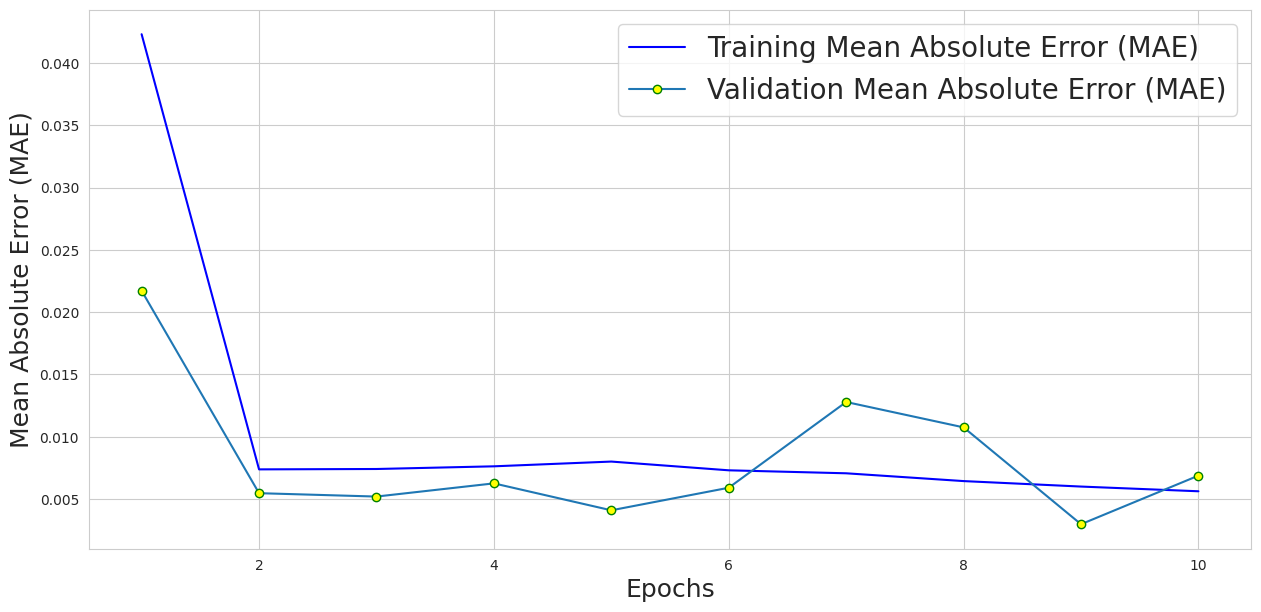

In [94]:
# More detailed MAE graph

history_dict = history.history

mae_values = history_dict['mae']
val_mae_values = history_dict['val_mae']

epochs = range(1, len(mae_values) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(epochs, mae_values, 'b', label='Training Mean Absolute Error (MAE)')
plt.plot(
    epochs,
    val_mae_values,
    marker='o',
    markeredgecolor='green',
    markerfacecolor='yellow',
    label='Validation Mean Absolute Error (MAE)'
)

plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Absolute Error (MAE)', size=18)

plt.legend()
plt.show()